# Week 2 — Notebook 1: Market Data Loading

In this notebook you will:
- Define project constants (paths, tickers, dates)
- Download OHLCV data for every market symbol and save it to `data/raw/`
- Explore the downloaded data and compute basic return statistics
- Compare multiple symbols with normalised return plots

Fill in every `# TODO` cell before moving to `technical_indicators.ipynb`.

---

## 0. Install & Import Libraries

In [8]:
# !pip install yfinance pandas numpy matplotlib  # uncomment on Colab / fresh env

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

print('Libraries imported!')

Libraries imported!


---

## 1. Project Configuration

Define all constants that the project relies on. These same constants are used in every notebook and script this week, so get them right here first.

| Constant | Purpose |
|---|---|
| `BASE_DIR` | Root of the project (notebook's working directory) |
| `RAW_DIR` | `BASE_DIR/data/raw` — raw OHLCV CSVs |
| `PROCESSED_DIR` | `BASE_DIR/data/processed` — feature-engineered CSVs |
| `START_DATE` | Earliest date to download (`"2015-01-01"`) |
| `END_DATE` | `None` → today |
| `MARKET_SYMBOLS` | Dict: market name → list of Yahoo Finance ticker strings |

> 💡 Use `Path.cwd()` as the base when running inside a notebook.

In [9]:
# TODO 1.1 — Define directory paths and create them on disk
BASE_DIR      = Path.cwd()
RAW_DIR       = BASE_DIR/"data"/"raw"
PROCESSED_DIR = BASE_DIR/"data"/"processed"

print('RAW_DIR      :', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

RAW_DIR      : /home/ajay/SOC/SOC-Stock-Trading-With-LSTM-And-RL/Week2/data/raw
PROCESSED_DIR: /home/ajay/SOC/SOC-Stock-Trading-With-LSTM-And-RL/Week2/data/processed


In [22]:
# TODO 1.2 — Define the date range and market symbol universe
START_DATE =     '2015-01-01'
END_DATE   =     None

#Load the market symbols in the readme as dictionary here
MARKET_SYMBOLS = {
    'india':  ['^NSEI','^BSESN','RELIANCE.NS','TCS.NS','INFY.NS'],
    'us':     ['^GSPC','^IXIC','SPY','MSFT','NVDA','TSLA'],
    'crypto': ['BTC-USD','ETH-USD'],
    'forex':  ['EURUSD=X','JPY=X'],
}

print('Markets :', list(MARKET_SYMBOLS.keys()))
print('Symbols :', sum(len(v) for v in MARKET_SYMBOLS.values()), 'total')

Markets : ['india', 'us', 'crypto', 'forex']
Symbols : 15 total


In [111]:
# TODO 1.3 — Implement safe_symbol()
# Converts a ticker into a filesystem-safe filename stem.
# Rules: drop '^', replace '.' '-' '=' with '_'
# Examples:
#   '^NSEI'       -> 'NSEI'
#   'RELIANCE.NS' -> 'RELIANCE_NS'
#   'BTC-USD'     -> 'BTC_USD'
#   'EURUSD=X'    -> 'EURUSD_X'
import re
def safe_symbol(symbol: str) -> str:
    symbol = re.sub(r"^\^(.+)$",r"\1",symbol)
    symbol = re.sub(r"^(.+)\.(.+)$",r"\1_\2",symbol)
    symbol = re.sub(r"^(.+)-(.+)$",r"\1_\2",symbol)
    symbol = re.sub(r"^(.+)=(.+)$",r"\1_\2",symbol)
    return symbol
# Smoke-test
assert safe_symbol('^NSEI')       == 'NSEI'
assert safe_symbol('RELIANCE.NS') == 'RELIANCE_NS'
assert safe_symbol('BTC-USD')     == 'BTC_USD'
assert safe_symbol('EURUSD=X')    == 'EURUSD_X'
print('safe_symbol() passed!')

safe_symbol() passed!


---

## 2. OHLCV Data Structure

Every downloaded file will have these columns (lowercase, normalised by us):

| Column | Description |
|---|---|
| `date` | Trading date |
| `open` | Price at market open |
| `high` | Intraday high |
| `low` | Intraday low |
| `close` | Price at market close |
| `adj_close` | Close adjusted for dividends and splits |
| `volume` | Shares / contracts traded |
| `symbol` | Ticker string (added by the download function) |

> The **close** price is used for all technical indicators. `adj_close` is preferred for long-term return calculations.

---

## 3. Download All Market Symbols → `data/raw/`

Implement the download pipeline step by step.

Each raw CSV must have lowercase column names, a `symbol` column, and be saved as `data/raw/<safe_symbol>.csv`.

In [112]:
# TODO 3.1 — Implement download_symbol()
# Downloads and cleans OHLCV data for a single ticker.
# Steps inside the function:
#   1. Call yf.download() with auto_adjust=False, progress=False
#   2. Raise ValueError if the result is empty
#   3. Flatten MultiIndex columns: keep only the first level
#      (yfinance sometimes returns a MultiIndex when downloading one symbol)
#   4. Reset the index so 'Date' becomes a regular column
#   5. Lowercase all column names; replace spaces with underscores
#   6. Add a 'symbol' column containing the ticker string

def download_symbol(symbol: str, start: str = START_DATE, end=END_DATE) -> pd.DataFrame:
    # 1. Call yf.download() function
    data = yf.download(symbol,auto_adjust=False,progress=False,start=START_DATE,end=END_DATE)
    # 2. Raise ValueError for check
    if data.empty :
        raise ValueError(f"NO DATA FOUND FOR SYMBOL: {symbol}")
    # 3. Flatten MultiIndex
    data.columns = data.columns.get_level_values(0)
    # 4. Reset index
    data = data.reset_index()
    # 5. Normalise column names
    data.columns = [col.lower().replace(" ","_") for col in data.columns]
    # 6. Add symbol column
    data["symbol"] = symbol

    return data

# Quick test
test_df = download_symbol('SPY')
print(test_df.shape)
print(test_df.columns.tolist())
test_df.head()

(2873, 8)
['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'symbol']


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,170.124985,205.429993,206.880005,204.179993,206.380005,121465900,SPY
1,2015-01-05,167.052582,201.720001,204.369995,201.350006,204.169998,169632600,SPY
2,2015-01-06,165.479187,199.820007,202.720001,198.860001,202.089996,209151400,SPY
3,2015-01-07,167.541153,202.309998,202.720001,200.880005,201.419998,125346700,SPY
4,2015-01-08,170.514282,205.899994,206.160004,203.990005,204.009995,147217800,SPY


In [113]:
# TODO 3.2 — Download every symbol and save to RAW_DIR
# Use a try/except so one failed ticker does not stop the loop.
from pathlib import Path
for market, symbols in MARKET_SYMBOLS.items():
    for symbol in symbols:
        try:
           df = download_symbol(symbol)
           filename = safe_symbol(symbol) + ".csv"
           filepath = RAW_DIR/filename
           df.to_csv(filepath)
           print(f"Saved {symbol}")
        except Exception as e:
            print(f"ERROR OCCURED WHILE DOWNLOADING THE DATA FOR SYMBOL: {symbol}")

Saved ^NSEI
Saved ^BSESN
Saved RELIANCE.NS
Saved TCS.NS
Saved INFY.NS
Saved ^GSPC
Saved ^IXIC
Saved SPY
Saved MSFT
Saved NVDA
Saved TSLA
Saved BTC-USD
Saved ETH-USD
Saved EURUSD=X
Saved JPY=X


---

## 4. Load & Explore a Single Symbol

Before computing indicators, get familiar with the raw data for one symbol.

In [114]:
# TODO 4.1 — Load SPY (or any symbol you like) from RAW_DIR
# Parse 'date' as datetime, sort ascending.

df = pd.read_csv('data/raw/RELIANCE_NS.csv')
df["date"] = pd.to_datetime(df['date'])
df.sort_values(by='date')
df = df.drop(columns=['Unnamed: 0'])
print('Shape :', df.shape)
print('Dtypes:\n', df.dtypes)
df.head()

Shape : (2822, 8)
Dtypes:
 date         datetime64[us]
adj_close           float64
close               float64
high                float64
low                 float64
open                float64
volume                int64
symbol                  str
dtype: object


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-01,189.125366,202.959000,203.896194,201.987518,202.593277,2963643,RELIANCE.NS
1,2015-01-02,188.624817,202.421829,204.821960,202.136108,203.004715,7331366,RELIANCE.NS
2,2015-01-05,186.558701,200.204575,203.644760,199.804550,202.296112,10103941,RELIANCE.NS
3,2015-01-06,178.091827,191.118393,199.553116,190.181198,198.867371,18627980,RELIANCE.NS
4,2015-01-07,181.968475,195.278610,196.307236,191.324127,191.346985,20720312,RELIANCE.NS


In [115]:
# TODO 4.2 — Compute and print the following statistics
#   1. Mean daily return (pct_change of close)
#   2. Daily return standard deviation (volatility)
#   3. Annualised volatility  →  daily_std * sqrt(252)
#   4. Total cumulative return over the full period
#   5. Date of the all-time high close
#   6. Date of the all-time low close
MDR = df['close'].pct_change().mean()
DR_STD = df['close'].pct_change().std() 
AV = DR_STD * (252 ** 0.5)
TCR = df['close'].iloc[-1] / df['close'].iloc[0] - 1
DATE_ALL_TIME_HIGH_CLOSE = df[df['close'] == df['close'].max()].date
DATE_ALL_TIME_LOW_CLOSE = df[df['close'] == df['close'].min()].date

print(MDR)
print(DR_STD)
print(AV)
print(TCR)
display(DATE_ALL_TIME_HIGH_CLOSE)
print(DATE_ALL_TIME_LOW_CLOSE)

0.0008005502822153319
0.01702815317594422
0.2703135515415786
5.360890634706655


2346   2024-07-08
Name: date, dtype: datetime64[us]

59   2015-03-30
Name: date, dtype: datetime64[us]


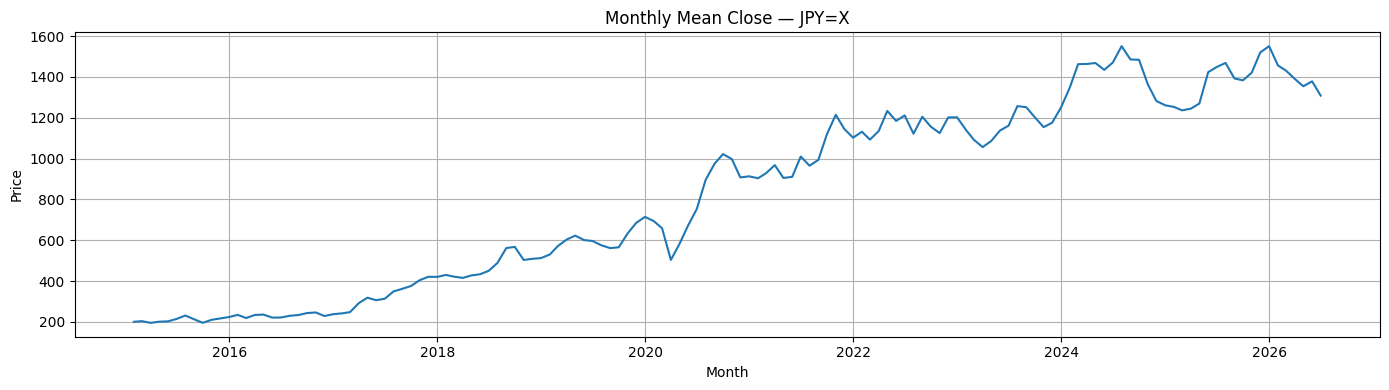

In [116]:
# TODO 4.3 — Resample close to monthly mean and plot as a line chart

monthly_close = df.set_index('date').resample('ME')['close'].mean()

plt.figure(figsize=(14, 4))
plt.plot(monthly_close)
plt.title(f'Monthly Mean Close — {symbol}')
plt.xlabel('Month'); plt.ylabel('Price')
plt.grid(True); plt.tight_layout(); plt.show()

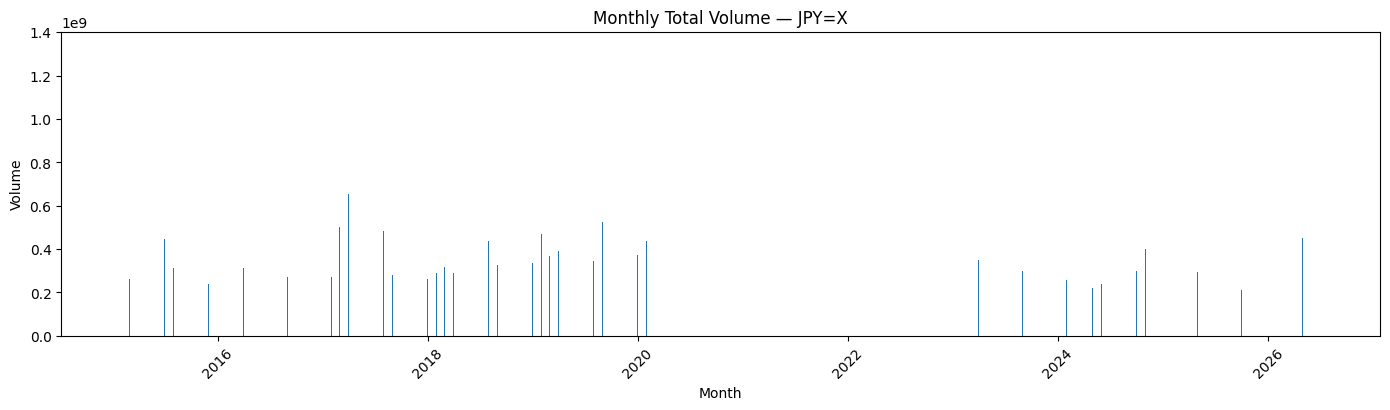

date
2015-01-31    341195325
2015-02-28    260067933
2015-03-31    306852638
2015-04-30    385228070
2015-05-31    289630758
                ...    
2026-02-28    216519077
2026-03-31    399688769
2026-04-30    449168049
2026-05-31    329539497
2026-06-30     95273066
Freq: ME, Name: volume, Length: 138, dtype: int64

In [117]:
# TODO 4.4 — Resample volume to monthly total and plot as a bar chart

monthly_vol = df.set_index('date')['volume'].resample('ME').sum()

plt.figure(figsize=(14, 4))
plt.bar(monthly_vol.index,monthly_vol.values)
plt.title(f'Monthly Total Volume — {symbol}')
plt.xlabel('Month'); plt.ylabel('Volume')
plt.tight_layout(); 
plt.xticks(rotation=45)
plt.show()
display(monthly_vol)

---

## 5. Multi-Symbol Comparison

Normalised cumulative returns let you compare symbols regardless of their absolute price level. Dividing each series by its first value sets every series to start at 1.0.

In [118]:
# TODO 5.1 — Load the Close price for all US symbols into one DataFrame
# Each column = one symbol. Align on date index, forward-fill any gaps.

us_closes = pd.DataFrame()
for sym in MARKET_SYMBOLS['us']:
    us_closes[sym] = download_symbol(sym)['close']
    us_closes['date'] = download_symbol(sym)['date']
us_closes = us_closes.set_index('date')
us_closes.sort_index()
us_closes.ffill()
display(us_closes)  


,^GSPC,^IXIC,SPY,MSFT,NVDA,TSLA
date,,,,,,
2015-01-02,2058.199951,4726.810059,205.429993,46.759998,0.503250,14.620667
2015-01-05,2020.579956,4652.569824,201.720001,46.330002,0.494750,14.006000
2015-01-06,2002.609985,4592.740234,199.820007,45.650002,0.479750,14.085333
2015-01-07,2025.900024,4650.470215,202.309998,46.230000,0.478500,14.063333
2015-01-08,2062.139893,4736.189941,205.899994,47.590000,0.496500,14.041333
...,...,...,...,...,...,...
2026-06-01,7599.959961,27086.810547,758.539978,460.519989,224.360001,415.880005
2026-06-02,7609.779785,27093.900391,759.570007,441.309998,222.820007,423.739990
2026-06-03,7553.680176,26853.980469,754.239990,427.339996,214.750000,423.700012


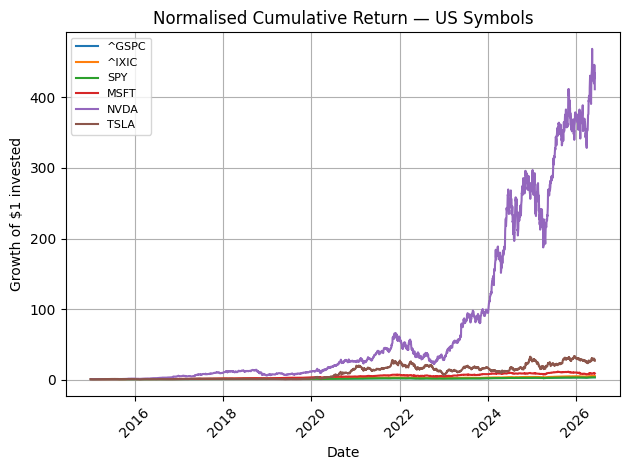

In [119]:
# TODO 5.2 — Normalise so each series starts at 1.0, then plot all on one chart
normalised = us_closes / us_closes.iloc[0]
for col in normalised.columns :
    plt.plot(normalised.index,normalised[col],label=col)
plt.title('Normalised Cumulative Return — US Symbols')
plt.ylabel('Growth of $1 invested'); plt.xlabel('Date'); plt.xticks(rotation=45)
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

,^NSEI,^BSESN,RELIANCE.NS,TCS.NS,INFY.NS
date,,,,,
2015-01-01,8395.450195,27887.900391,202.959000,1272.775024,493.600006
2015-01-02,8378.400391,27842.320312,202.421829,1289.724976,503.299988
2015-01-05,8127.350098,26987.460938,200.204575,1270.125000,498.975006
2015-01-06,8102.100098,26908.820312,191.118393,1223.300049,488.549988
2015-01-07,8234.599609,27274.710938,195.278610,1208.849976,490.887512
...,...,...,...,...,...
2026-05-15,23382.599609,74649.843750,1336.400024,2264.000000,1119.000000
2026-05-18,23483.550781,74346.171875,1335.900024,2283.199951,1142.500000
2026-05-19,23405.599609,74360.007812,1322.699951,2327.100098,1196.900024


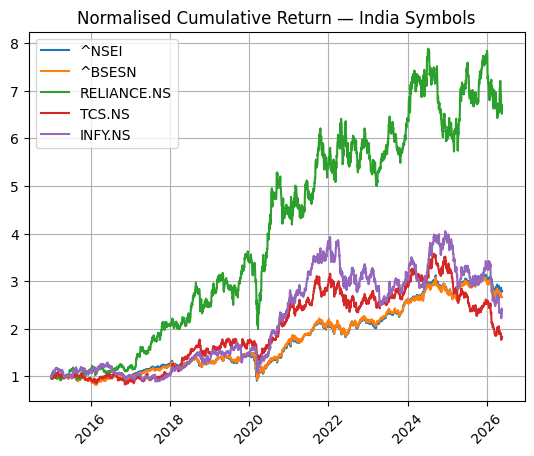

In [121]:
# TODO 5.3 — Repeat for India symbols

india_closes = pd.DataFrame()
for sym in MARKET_SYMBOLS['india']:
    india_closes[sym] = download_symbol(sym)['close']
    india_closes['date'] = download_symbol(sym)['date']
india_closes = india_closes.set_index('date')
india_closes.sort_index
display(india_closes)
# plot normalised series
normalised_india = india_closes / india_closes.iloc[0]
for col in normalised_india.columns:
    plt.plot(normalised_india.index,normalised_india[col],label=col)
plt.title('Normalised Cumulative Return — India Symbols')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

---
